# **1**

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
df = pd.read_csv(r"D:\studystudy\Window Dressing\merged data\reg1.csv")
df['MasterFundCode'] = df['MasterFundCode'].astype(str).str.zfill(6)
df  = df['MasterFundCode'].copy()
u = df.dropna().astype(str).drop_duplicates()
u.to_csv(r"D:\studystudy\Window Dressing\raw data\Flow\fund_list.txt",
         index=False, header=False, sep="\t")

In [3]:
df_flow1 = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\Flow\Fund_Allocation.csv")
df_flow2 = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\Flow\Fund_Allocation1.csv")
df_flow = pd.concat([df_flow1,df_flow2])
df_flow = df_flow[df_flow['CrossCode'] == 1].copy()
df_flow["EndDate"] = pd.to_datetime(df_flow["EndDate"], errors="coerce")
df_flow["Year"] = df_flow["EndDate"].dt.year.astype("Int64")
df_flow["Quarter"] = df_flow["EndDate"].dt.quarter.astype("Int64")
df_flow = df_flow.drop_duplicates(subset=['MasterFundCode',"Year", "Quarter"], keep="last")
df_flow['MasterFundCode'] = df_flow['MasterFundCode'].astype(str).str.zfill(6)

In [4]:
path0 = r"D:\studystudy\Window Dressing\raw data\Flow\Fund_NAV_Month.csv"
path1 = r"D:\studystudy\Window Dressing\raw data\Flow\Fund_NAV_Month1.csv"
df1 = pd.concat([pd.read_csv(path0), pd.read_csv(path1)], ignore_index=True)
df_s2m = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\independent variable\Alpha\FUND_FundCodeInfo.csv")
map_s2m = df_s2m[['Symbol', 'MasterFundCode']].drop_duplicates(subset=['Symbol'])

In [5]:
df_work = df1.copy()
df_work["TradingDate"] = pd.to_datetime(df_work["TradingDate"], errors="coerce")
df_work["Year"] = df_work["TradingDate"].dt.year.astype("Int64")
df_work["Quarter"] = df_work["TradingDate"].dt.quarter.astype("Int64")
df_work["Symbol"] = pd.to_numeric(df_work["Symbol"], errors="coerce").astype("Int64")
df_work = df_work.merge(map_s2m, on="Symbol", how="left")
df_work["r_m"] = pd.to_numeric(df_work["ReturnAccumulativeNAV"], errors="coerce")
df_ret_q = (
    df_work.dropna(subset=["MasterFundCode", "Year", "Quarter", "r_m"])
          .groupby(["MasterFundCode", "Year", "Quarter"], as_index=False)
          .agg(ReturnAccNAV_Q=("r_m", "prod"), N_months=("r_m", "size")))
df_ret_q["ReturnAccNAV_Q"] = df_ret_q["ReturnAccNAV_Q"] - 1.0
df_ret_q["MasterFundCode"] = df_ret_q["MasterFundCode"].astype("Int64").astype(str).str.zfill(6)
df_ret_q = (df_ret_q.sort_values(["MasterFundCode", "Year", "Quarter"])
            .reset_index(drop=True))

In [6]:
keys = ["MasterFundCode", "Year", "Quarter"]
df_ret_q_u = (df_ret_q.sort_values(keys)
            .drop_duplicates(subset=keys, keep="last")
            .reset_index(drop=True))
df_flow_q_u = (df_flow.sort_values(keys)
             .drop_duplicates(subset=keys, keep="last")
             .reset_index(drop=True))
df_merged = (df_ret_q_u.merge(df_flow_q_u, on=keys,how="inner",validate="one_to_one" )
    .sort_values(keys)
    .reset_index(drop=True))

In [7]:
keys = ["MasterFundCode", "Year", "Quarter"]
df = df_merged.copy()
df = df.sort_values(keys).reset_index(drop=True)
df["TNA_t"] = pd.to_numeric(df["TotalAsset"], errors="coerce")
df["r_t"]   = pd.to_numeric(df["ReturnAccNAV_Q"], errors="coerce")  # <- 如列名不同，在此替换
df["TNA_t_1"] = df.groupby("MasterFundCode")["TNA_t"].shift(1)
df["Flow"] = (df["TNA_t"] - df["TNA_t_1"] * (1.0 + df["r_t"])) / df["TNA_t_1"]

In [8]:
df = df[["MasterFundCode", "Year", "Quarter", "Flow"]].copy()
df.to_csv(r'D:\studystudy\Window Dressing\raw data\Flow\fund_flow.csv')

In [9]:
df_reg = pd.read_csv(r"D:\studystudy\Window Dressing\merged data\reg1.csv") 
df = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\Flow\fund_flow.csv") 

In [10]:
df_reg = df_reg.copy()
df_reg['MasterFundCode'] = df_reg['MasterFundCode'].astype(str).str.zfill(6)
df_reg['Period'] = df_reg['Year'] * 2 + df_reg['Half']
df_reg['WDdummy_RankGap'] = (
    df_reg
    .groupby('Period')['RankGap']
    .transform(lambda x: (x >= x.quantile(0.9)).astype(int)))
df_reg['WDdummy_resBHRG'] = (
    df_reg
    .groupby('Period')['resBHRG']
    .transform(lambda x: (x >= x.quantile(0.9)).astype(int)))
df_reg.drop(columns='Period', inplace=True)

In [11]:
flow_cols = ["Flow"]
df_reg = df_reg.copy()
df['MasterFundCode'] = df['MasterFundCode'].astype(str).str.zfill(6)
df_reg["Year"] = df_reg["Year"].astype("Int64")
df_reg["Half"] = df_reg["Half"].astype("Int64")
df["Year"] = df["Year"].astype("Int64")
df["Quarter"] = df["Quarter"].astype("Int64")
df_reg["MatchYear"] = df_reg["Year"] + (df_reg["Half"] == 2).astype("int")
df_reg["MatchQuarter"] = np.where(df_reg["Half"] == 1, 3, 1).astype("int")
df_q = df[["MasterFundCode", "Year", "Quarter"] + flow_cols].copy()
df_q = df_q.rename(columns={"Year": "MatchYear", "Quarter": "MatchQuarter"})
df_reg_matched = df_reg.merge(df_q, on=["MasterFundCode", "MatchYear", "MatchQuarter"], how="left")

In [12]:
df_reg_matched[["Half","Year","MatchYear","MatchQuarter"]].drop_duplicates().sort_values(["Year","Half"])
df_reg_matched["matched"] = df_reg_matched[flow_cols[0]].notna()
df_reg_matched["matched"].mean()

0.9966986509595288

In [13]:
#winsorization
X_cols = ['BHRG','Flow','RankGap','resBHRG','Inst_i,t-1','Alpha_i,t','Expense_i,t','Turnover_i,t','LnTNA_i,t','ManagerSkill_i,t-1']
df_w = df_reg_matched.copy()
q01 = df_w[X_cols].quantile(0.03)
q99 = df_w[X_cols].quantile(0.97)
df_w[X_cols] = df_w[X_cols].clip(q01, q99, axis=1)
df_reg_matched = df_w.copy()

In [14]:
from linearmodels.iv import AbsorbingLS
df = df_reg_matched.copy()
df = df[df["matched"] == True].copy()
df["MasterFundCode"] = df["MasterFundCode"].astype(str)
df["InvestmentStyle"] = df["InvestmentStyle"].astype("category")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype(int)  
df["Flow"] = pd.to_numeric(df["Flow"], errors="coerce").astype(float)
base_x = [ "Alpha_i,t", "Expense_i,t", "Turnover_i,t", "LnTNA_i,t", "ManagerSkill_i,t-1"]
for c in base_x + ["WDdummy_RankGap", "WDdummy_resBHRG"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype(float)
absorb = df[["InvestmentStyle", "Year"]]
clusters = df["MasterFundCode"]
def run_absorbing_ls(wd_col: str):
    d = df.copy()
    d["WD_x_Inst"] = d[wd_col] * d["Inst_i,t-1"]
    X = d[[wd_col, "Inst_i,t-1", "WD_x_Inst"] + base_x].copy()
    X.insert(0, "const", 1.0)
    y = d["Flow"]
    use = pd.concat([y, X, absorb, clusters], axis=1).dropna()
    y2 = use["Flow"]
    X2 = use[X.columns]
    absorb2 = use[["InvestmentStyle", "Year"]]
    clusters2 = use["MasterFundCode"]
    mod = AbsorbingLS(y2, X2, absorb=absorb2)
    res = mod.fit(cov_type="clustered", clusters=clusters2) 
    return res
res1 = run_absorbing_ls("WDdummy_RankGap")
res2 = run_absorbing_ls("WDdummy_resBHRG")
print(res1.summary)
print("\n" + "="*120 + "\n")
print(res2.summary)

                         Absorbing LS Estimation Summary                          
Dep. Variable:                   Flow   R-squared:                          0.0263
Estimator:               Absorbing LS   Adj. R-squared:                     0.0259
No. Observations:               41965   F-statistic:                        981.60
Date:                Sun, Jan 25 2026   P-value (F-stat):                   0.0000
Time:                        16:18:29   Distribution:                      chi2(8)
Cov. Estimator:             clustered   R-squared (No Effects):             0.0250
                                        Variables Absorbed:                10.0000
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  1.5873     0.0251     63.151     0.0000      1.5380 

In [15]:
cols = ['Flow','BHRG','RankGap','resBHRG','Inst_i,t-1','Alpha_i,t','Expense_i,t','Turnover_i,t','LnTNA_i,t','ManagerSkill_i,t-1']
desc = df[cols].agg(['count','mean','std','min','median','max']).T
desc['p25'] = df[cols].quantile(0.25)
desc['p75'] = df[cols].quantile(0.75)
desc = desc[['count','mean','std','min','p25','median','p75','max']]
#desc

# **2**

In [16]:
df_nav1 = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\independent variable\Alpha\Fund_NAV_Month.csv")
df_nav2 = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\independent variable\Alpha\Fund_NAV_Month1.csv")
df_nav = pd.concat([df_nav1 , df_nav2])
df_nav = df_nav.merge(map_s2m, on="Symbol", how="left")
def year_half(df_yh,time_col):
    out = df_yh.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors="coerce")
    out['Year'] = out[time_col].dt.year.astype("Int64")
    q = out[time_col].dt.quarter.astype("Int64")
    out["Half"] = q.map({1: 1, 2: 1, 3: 2, 4: 2}).astype("Int64")
    out.drop(columns=[time_col], inplace = True)
    return out
df_nav = year_half(df_nav,"TradingMonth")
df_nav.sort_values(["MasterFundCode", "TradingDate"], inplace=True)
df_nav["sigma_12m"] = (
df_nav.groupby("MasterFundCode")["ReturnAccumulativeNAV"]
.rolling(window=12, min_periods=12)
.std()
.reset_index(level=0, drop=True))
df_nav["Std_monthly"] = df_nav["sigma_12m"] * (12 ** 0.5)
key = ["MasterFundCode", "Year", "Half"]
df_nav["Std"] = df_nav.groupby(key)["Std_monthly"].transform("last")
df_nav.drop_duplicates(subset=['MasterFundCode',"Year", "Half"], keep="last",inplace = True)
df_std = df_nav[['MasterFundCode','Year','Half','Std']]

In [17]:
df_div = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\Flow\Fund_FundDividend.csv")
df_div = year_half(df_div,"AnnouncementDate")
df_div = df_div.merge(map_s2m, on="Symbol", how="left")
df_div.drop(columns = 'Symbol' , inplace =True)
df_div = (
    df_div.assign(_pos = df_div["DividendperShare"].gt(0))
          .groupby(key, as_index=False)
          .agg(
              Num_div=("_pos", "sum"),
              Sum_div=("DividendperShare", "sum")))
df_div.drop_duplicates(subset=['MasterFundCode',"Year", "Half"], inplace = True)

In [18]:
df_fam = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\Flow\FUND_MainInfo.csv")
df_fam = year_half(df_fam ,'InceptionDate')
df_fam.rename(columns = {'Year':'InceptionYear'},inplace = True)
df_fam.drop(columns = ['Half','FullName'], inplace = True)
df_fam.drop_duplicates(subset="MasterFundCode",inplace = True)

In [19]:
df_ta = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\independent variable\others\FUND_FIN_Balance.csv")
df_ta = df_ta[['MasterFundCode','EndDate','TotalAsset']]
df_ta = year_half(df_ta , 'EndDate')
df_ta = df_ta.drop_duplicates(subset=['MasterFundCode',"Year", "Half"], keep="last")
df_ta['LnTNA_i,t'] = np.log(df_ta['TotalAsset'])
df_ta_fam = df_ta.merge(df_fam , on = 'MasterFundCode' ,how = 'left')
df_tf = df_ta_fam.copy()
df_tf['FamTotalAsset'] = df_tf.groupby(['Year','Half','FundCompanyID'])['TotalAsset'].transform('sum')
df_tf['LnFamSize_i,t'] = np.log(df_tf['FamTotalAsset'])
df_ta_fam = df_ta_fam.merge(df_tf[['Year','Half','MasterFundCode','LnFamSize_i,t']] , on = ['Year','Half','MasterFundCode'] ,how = 'left')
df_ta_fam['LnAge'] = np.log(df_ta_fam['Year'] - df_ta_fam['InceptionYear'] + 1)
df_all = df_ta_fam.merge(df_nav ,on = key ,how = 'left')
df_all = df_all.merge(df_div , on = key , how = 'left')
df_all['Num_div'] = df_all['Num_div'].fillna(0)
df_all['Sum_div'] = df_all['Sum_div'].fillna(0)
df_cv = df_all[['MasterFundCode','Year','Half','Sum_div','Num_div','Std','LnFamSize_i,t','LnTNA_i,t','LnAge']]

C:\Users\MLTZ\AppData\Local\conda\conda\envs\anaconda-finance\Lib\site-packages\pandas\core\arrays\masked.py:691: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


In [20]:
df_flow = pd.concat([df_flow1,df_flow2])
df_flow = df_flow[df_flow['CrossCode'] == 1].copy()
df_flow = year_half(df_flow,"EndDate")
df_flow = df_flow.drop_duplicates(subset=['MasterFundCode',"Year", "Half"], keep="last")
df_nav_h = pd.concat([df_nav1 , df_nav2])
df_nav_h = df_nav_h.merge(map_s2m, on="Symbol", how="left")
df_nav_h = year_half(df_nav_h,"TradingMonth")
df_nav_h['ReturnAccumulativeNAV'] += 1 
df_nav_h = df_nav_h.groupby(['Year','Half','MasterFundCode'], as_index=False)['ReturnAccumulativeNAV'].prod()
df_nav_h['ReturnAccumulativeNAV'] -= 1 
df_merged = (df_nav_h.merge(df_flow, on=key,how="inner",validate="one_to_one")
    .sort_values(key)
    .reset_index(drop=True))
df_merged = df_merged.sort_values(key).reset_index(drop=True)
df_merged["TotalAsset_1"] = df_merged.groupby("MasterFundCode")["TotalAsset"].shift(1)
df_merged["Flow"] = (df_merged["TotalAsset"] - df_merged["TotalAsset_1"] * (1.0 + df_merged["ReturnAccumulativeNAV"])) / df_merged["TotalAsset_1"]
df_flow_h = df_merged[['MasterFundCode','Year','Half','Flow']]

In [21]:
df_reg8 = pd.read_csv(r"D:\studystudy\Window Dressing\merged data\reg1.csv")[['MasterFundCode','Year','Half','Alpha_i,t','Inst_i,t-1']]
df_reg8 = df_reg8.merge(df_flow_h, on = key , how = 'left')
df_reg8 = df_reg8.merge(df_all[['MasterFundCode','Year','Half','Sum_div','Num_div',
                                'Std','LnFamSize_i,t','LnTNA_i,t','LnAge']], on = key , how = 'left')
df_reg8['Alpha_i,t-1'] = df_reg8.groupby('MasterFundCode')['Alpha_i,t'].shift(1)
df_reg8['Alpha_i,t-1×Inst_i,t-1'] = df_reg8['Alpha_i,t-1'] * df_reg8['Inst_i,t-1']

In [22]:
#winsorization
w_cols = ['Alpha_i,t-1','Alpha_i,t-1×Inst_i,t-1','Std','LnFamSize_i,t','LnTNA_i,t','Flow']
df_w = df_reg8.copy()
q01 = df_w[w_cols].quantile(0.025)
q99 = df_w[w_cols].quantile(0.975)
df_w[w_cols] = df_w[w_cols].clip(q01, q99, axis=1)
df_reg8 = df_w.copy()

In [23]:
from linearmodels.iv import AbsorbingLS 
cols_x = ['Alpha_i,t-1','Alpha_i,t-1×Inst_i,t-1','Sum_div','Num_div',
          'Std','LnFamSize_i,t','LnTNA_i,t','LnAge']
cols_all = ['Flow', 'Year', 'MasterFundCode'] + cols_x
reg_df = df_reg8[cols_all].dropna()
y_clean = reg_df['Flow']
X_clean = reg_df[cols_x]
absorb = reg_df[['Year']].astype('category')
clusters = reg_df['MasterFundCode']
mod = AbsorbingLS(y_clean, X_clean, absorb=absorb)
res = mod.fit(cov_type='clustered', clusters=clusters)
print(res.summary)

                         Absorbing LS Estimation Summary                          
Dep. Variable:                   Flow   R-squared:                          0.0677
Estimator:               Absorbing LS   Adj. R-squared:                     0.0671
No. Observations:               37328   F-statistic:                        1266.8
Date:                Sun, Jan 25 2026   P-value (F-stat):                   0.0000
Time:                        16:18:33   Distribution:                      chi2(8)
Cov. Estimator:             clustered   R-squared (No Effects):             0.0555
                                        Variables Absorbed:                 18.000
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
Alpha_i,t-1                0.5411     0.0661     8.1830     0.0

In [24]:
cols = ['Alpha_i,t-1','Alpha_i,t-1×Inst_i,t-1','Sum_div','Num_div',
          'Std','LnFamSize_i,t','LnTNA_i,t','LnAge','Flow']
desc = df_reg8[cols].agg(['count','mean','std','min','median','max']).T
desc['p25'] = df_reg8[cols].quantile(0.25)
desc['p75'] = df_reg8[cols].quantile(0.75)
desc = desc[['count','mean','std','min','p25','median','p75','max']]
#desc

# **3**

In [25]:
df_reg10 = df_reg8.copy()

In [26]:
key = ["Year", "Half"]
xcol = "Inst_i,t-1"
n_in_group = df_reg10.groupby(key)[xcol].transform("size")
r_in_group = df_reg10.groupby(key)[xcol].rank(method="first", ascending=False)
p_in_group = (r_in_group - 1) / n_in_group
g = (p_in_group * 5).astype("int64") + 1  # 1=top20%, ... , 5=bottom20%
df_reg10["Group1_i,t-1"] = (g == 1).astype("int8")
df_reg10["Group2_i,t-1"] = (g == 2).astype("int8")
df_reg10["Group3_i,t-1"] = (g == 3).astype("int8")
df_reg10["Group4_i,t-1"] = (g == 4).astype("int8")
alpha_col = "Alpha_i,t-1"
groups = ["Group1_i,t-1", "Group2_i,t-1", "Group3_i,t-1", "Group4_i,t-1"]
for gcol in groups:
    df_reg10[alpha_col + "×" + gcol] = df_reg10[alpha_col] * df_reg10[gcol]

In [27]:
from linearmodels.iv import AbsorbingLS 
cols_x = ['Alpha_i,t-1','Alpha_i,t-1×Group1_i,t-1','Alpha_i,t-1×Group2_i,t-1','Alpha_i,t-1×Group3_i,t-1',
          'Alpha_i,t-1×Group4_i,t-1','Sum_div','Num_div','Std','LnFamSize_i,t','LnTNA_i,t','LnAge']
cols_all = ['Flow', 'Year', 'MasterFundCode'] + cols_x
reg_df = df_reg10[cols_all].dropna()
y_clean = reg_df['Flow']
X_clean = reg_df[cols_x]
absorb = reg_df[['Year']].astype('category')
clusters = reg_df['MasterFundCode']
mod = AbsorbingLS(y_clean, X_clean, absorb=absorb)
res = mod.fit(cov_type='clustered', clusters=clusters)
print(res.summary)

                         Absorbing LS Estimation Summary                          
Dep. Variable:                   Flow   R-squared:                          0.0680
Estimator:               Absorbing LS   Adj. R-squared:                     0.0673
No. Observations:               37328   F-statistic:                        1280.3
Date:                Sun, Jan 25 2026   P-value (F-stat):                   0.0000
Time:                        16:18:34   Distribution:                     chi2(11)
Cov. Estimator:             clustered   R-squared (No Effects):             0.0558
                                        Variables Absorbed:                 18.000
                                    Parameter Estimates                                     
                          Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------------
Alpha_i,t-1                  0.3426     0.1284     2.6689

# **Something more than replication**

## **figures**

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

In [33]:
df_fig_raw = pd.read_csv(r"D:\studystudy\Window Dressing\merged data\reg1.csv")
X_cols = ['BHRG','RankGap','resBHRG','Inst_i,t-1','Alpha_i,t','Expense_i,t','Turnover_i,t','LnTNA_i,t','ManagerSkill_i,t-1']
df_w = df_fig_raw.copy()
q01 = df_w[X_cols].quantile(0.01)
q99 = df_w[X_cols].quantile(0.99)
df_w[X_cols] = df_w[X_cols].clip(q01, q99, axis=1)
df_fig_raw = df_w.copy()

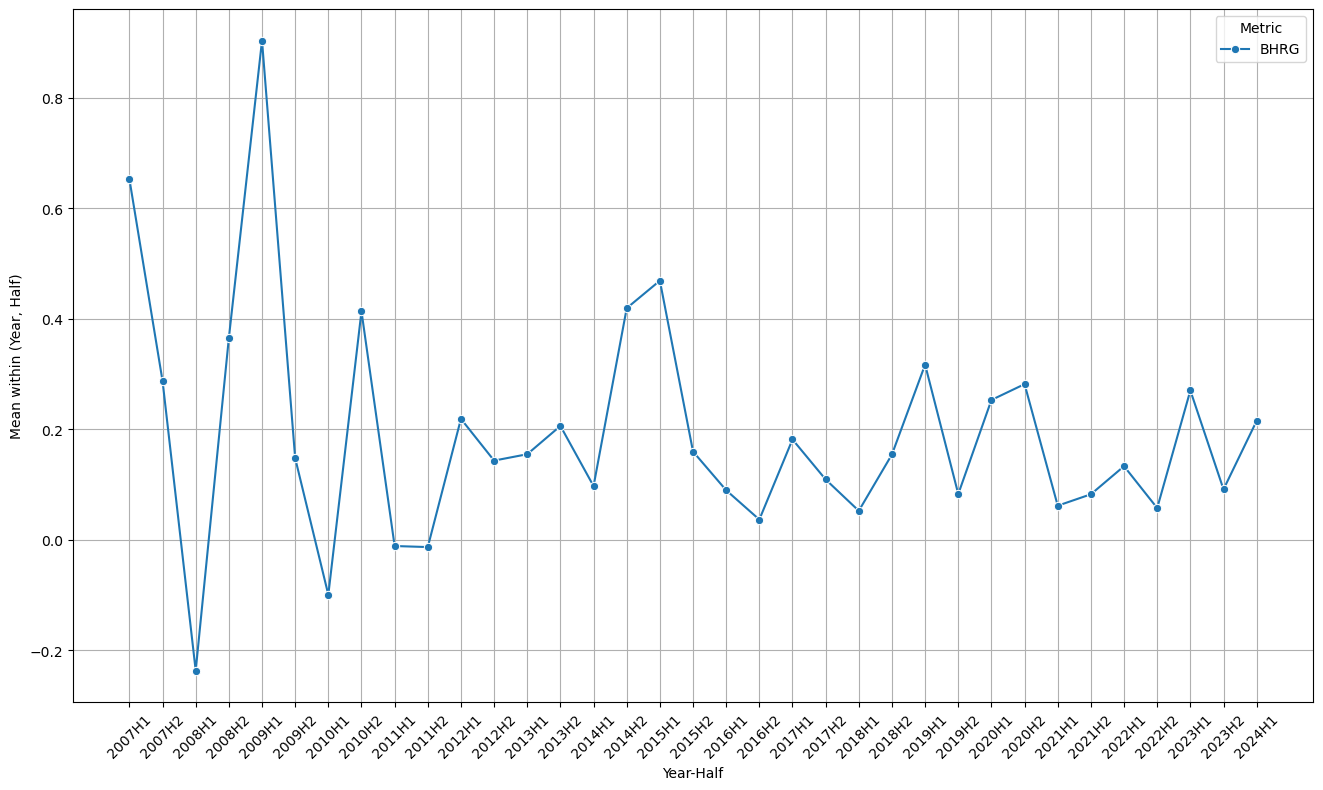

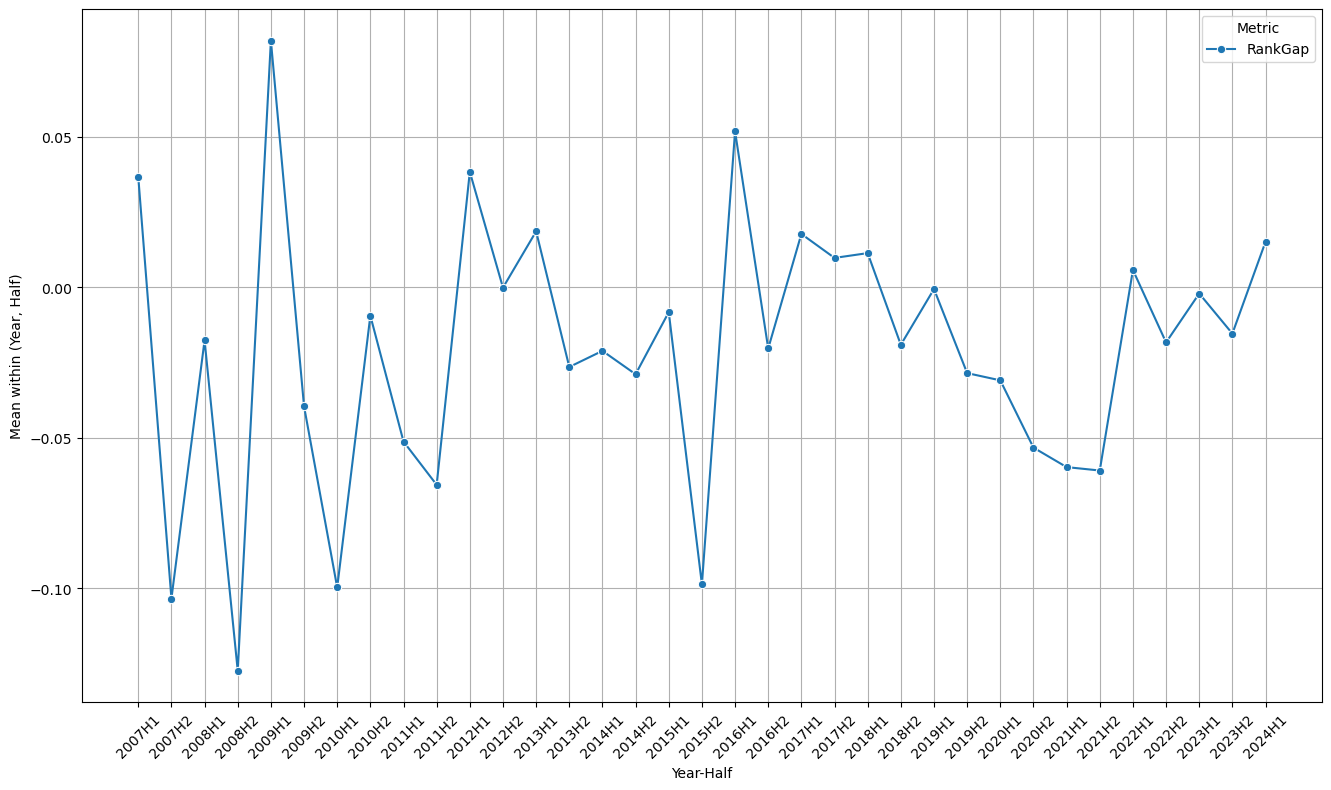

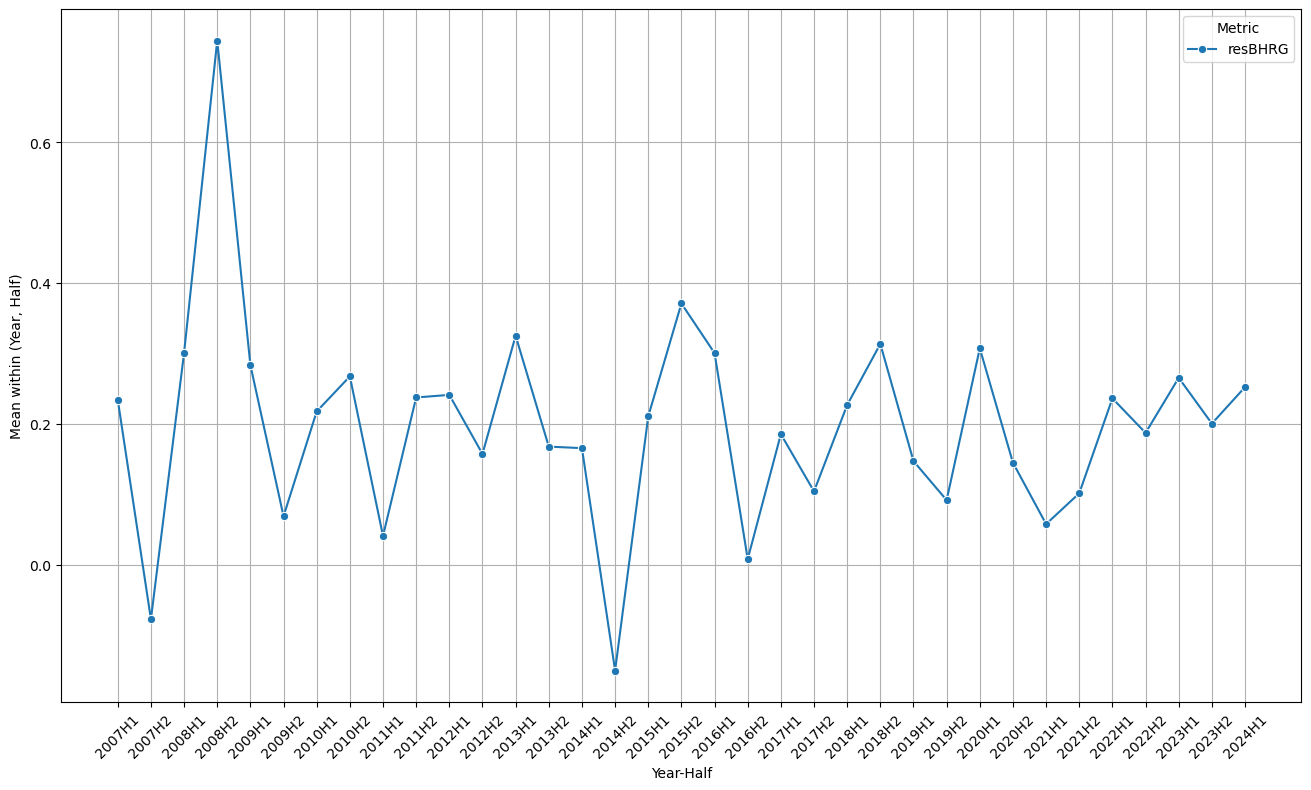

In [58]:
for i in ["BHRG", "RankGap", "resBHRG"]:
    agg = (df_fig_raw.groupby(["Year", "Half"], as_index=False)[i].mean())
    agg["YearHalf"] = agg["Year"].astype(str) + "H" + agg["Half"].astype(str)
    agg = agg.sort_values(["Year", "Half"]).reset_index(drop=True)
    long = agg.melt(
    id_vars=["Year", "Half", "YearHalf"],
    value_vars=i,
    var_name="Metric",
    value_name="Value")
    plt.figure(figsize=(16, 9))
    ax = sns.lineplot(
    data=long,
    x="YearHalf",
    y="Value",
    hue="Metric",
    marker="o")
    ax.set_xlabel("Year-Half")
    ax.set_ylabel("Mean within (Year, Half)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)

In [44]:
df_manager = pd.read_csv(r"D:\studystudy\Window Dressing\raw data\funds info\Fund_FundManager.csv")

In [45]:
df_manager["Male"] = df_manager["Gender"].map({'男': 1, '女': 0})
def Master_map(x):
    Master = 1 if x in ['硕士研究生','博士研究生','MBA/EMBA'] else 0
    return Master
def Chinese_map(x):
    Chinese = 1 if x =='中华人民共和国' else 0
    return Chinese
df_manager["Master"] = df_manager["Degree"].map(Master_map)
df_manager["Chinese"] = df_manager["Nationality"].map(Chinese_map)
df_manager['BusinessDuration'] = df_manager['BusinessDuration'].fillna(0)
df_manager = df_manager[['MasterFundCode','FullName','ServiceStartDate','Male','Master','Chinese','BusinessDuration','PositionState']]

In [46]:
df_manager["ServiceStartDate"] = pd.to_datetime(df_manager["ServiceStartDate"], errors="coerce")
df_manager = df_manager.sort_values(["MasterFundCode", "ServiceStartDate"]).reset_index(drop=True)

tmp = (
    df_manager[["MasterFundCode", "ServiceStartDate"]]
    .drop_duplicates(["MasterFundCode", "ServiceStartDate"])
    .sort_values(["MasterFundCode", "ServiceStartDate"])
)
tmp["NextStartDate"] = tmp.groupby("MasterFundCode")["ServiceStartDate"].shift(-1)

df_manager = df_manager.merge(tmp, on=["MasterFundCode", "ServiceStartDate"], how="left")

# 关键：没有下一任的，用一个足够大的日期填充
sample_end = pd.Timestamp("2099-12-31")
df_manager["EndDate"] = df_manager["NextStartDate"].fillna(sample_end)
start_year = int(df_manager["ServiceStartDate"].dt.year.min())
end_year = int(df_manager["ServiceStartDate"].dt.year.max())

years = pd.Series(range(start_year, end_year + 1), name="Year")
periods = years.to_frame().merge(
    pd.DataFrame({"Half": [1, 2]}), how="cross"
)

periods["HalfEndDate"] = pd.to_datetime(
    periods["Year"].astype(str)
    + "-"
    + periods["Half"].map({1: "06-30", 2: "12-31"})
)

funds = df_manager[["MasterFundCode"]].drop_duplicates()
fund_periods = funds.merge(periods, how="cross")

df_mgr_halfend = (
    fund_periods.merge(df_manager, on="MasterFundCode", how="left")
    .loc[
        lambda x: (x["ServiceStartDate"] <= x["HalfEndDate"])
        & (x["HalfEndDate"] < x["EndDate"])
    ]
    .reset_index(drop=True)
)
start_year = int(df_manager["ServiceStartDate"].dt.year.min())
end_year = int(df_manager["ServiceStartDate"].dt.year.max())

years = pd.Series(range(start_year, end_year + 1), name="Year")
periods = years.to_frame().merge(
    pd.DataFrame({"Half": [1, 2]}), how="cross"
)

periods["HalfEndDate"] = pd.to_datetime(
    periods["Year"].astype(str)
    + "-"
    + periods["Half"].map({1: "06-30", 2: "12-31"})
)

funds = df_manager[["MasterFundCode"]].drop_duplicates()
fund_periods = funds.merge(periods, how="cross")

df_mgr_halfend = (
    fund_periods.merge(df_manager, on="MasterFundCode", how="left")
    .loc[
        lambda x: (x["ServiceStartDate"] <= x["HalfEndDate"])
        & (x["HalfEndDate"] < x["EndDate"])
    ]
    .reset_index(drop=True)
)
cols_mean = ["Male", "Master", "Chinese", "BusinessDuration"]
df_mgr_half_final = (
    df_mgr_halfend
    .groupby(["MasterFundCode", "Year", "Half"], as_index=False)[cols_mean]
    .mean()
)

In [49]:
df_reg_mgr = df_fig_raw.merge(df_mgr_half_final , on = ['MasterFundCode','Year','Half'] , how = 'left')

In [53]:
from linearmodels.iv import AbsorbingLS
for i in ['BHRG','resBHRG', 'RankGap']:
    # 1) 准备 y, X
    y = df_reg_mgr[i]
    X = df_reg_mgr[['Inst_i,t-1', 'Alpha_i,t', 'Expense_i,t', 'Turnover_i,t', 'LnTNA_i,t', "Male", "Master", "Chinese", "BusinessDuration"]]
    # 2) 固定效应（Style + Year）
    effects = df_reg_mgr[['InvestmentStyle', 'Year']].astype('category')
    # 3) 拼成回归用的数据，并去掉缺失（保证 y/X/effects 同步）
    reg_df = pd.concat([y, X, effects], axis=1).dropna()
    y_clean = reg_df[i]
    X_clean = reg_df[['Inst_i,t-1', 'Alpha_i,t', 'Expense_i,t', 'Turnover_i,t', 'LnTNA_i,t', "Male", "Master", "Chinese", "BusinessDuration"]]
    effects_clean = reg_df[['InvestmentStyle', 'Year']].astype('category')
    # 4) 估计：AbsorbingLS 会自动包含截距（等价于有 constant）
    mod = AbsorbingLS(y_clean, X_clean, absorb=effects_clean)
    # 5) 标准误：先用稳健（HC1 类似）
    res = mod.fit(
        cov_type='clustered',
        clusters=df_reg.loc[y_clean.index, 'MasterFundCode'])
    print(res.summary)
    print('\n'*3)

                         Absorbing LS Estimation Summary                          
Dep. Variable:                   BHRG   R-squared:                          0.1670
Estimator:               Absorbing LS   Adj. R-squared:                     0.1663
No. Observations:               42104   F-statistic:                        1801.1
Date:                Sun, Jan 25 2026   P-value (F-stat):                   0.0000
Time:                        16:32:15   Distribution:                      chi2(9)
Cov. Estimator:             clustered   R-squared (No Effects):             0.0887
                                        Variables Absorbed:                 27.000
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
Inst_i,t-1          -0.0005  4.468e-05    -11.463     0.0000     -0.0006     -0.0